# Setup

In [1]:
%pip install --quiet seaborn ydata_profiling==4.12.2 git+https://github.com/pycaret/pycaret.git@master

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [2]:
# upload data
from google.colab import files
uploaded = files.upload()

Saving rooster_a3_discount.xlsx to rooster_a3_discount (1).xlsx


In [3]:
# format figures for display in Canvas

import seaborn as sns

sns.set_theme(style="white", rc={"figure.figsize": (12, 6)})
sns.set_context("notebook", font_scale=1.25, rc={"lines.linewidth": 2.5})

#Data Loading

In [4]:
import pandas as pd

orders = pd.read_excel("/content/rooster_a3_discount.xlsx", sheet_name="orders")
products = pd.read_excel("/content/rooster_a3_discount.xlsx", sheet_name="products")
customers = pd.read_excel("/content/rooster_a3_discount.xlsx", sheet_name="customers")
newsletters = pd.read_excel("/content/rooster_a3_discount.xlsx", sheet_name="newsletters")
metrics = pd.read_excel("/content/rooster_a3_discount.xlsx", sheet_name="metrics")
pricing = pd.read_excel("/content/rooster_a3_discount.xlsx", sheet_name="pricing")
metadata = pd.read_excel("/content/rooster_a3_discount.xlsx", sheet_name="metadata")

In [5]:
# check that the data is loaded correctly

metadata_dict = {r[0]: r[1] for r in metadata.values}
print(f"""
Assessment scenario is {metadata_dict["Scenario"]}.
The data was extracted using schema version {metadata_dict["Version"]}.
""")
metadata


Assessment scenario is Discount strategy (5).
The data was extracted using schema version 22804-11.



,Field,Value
0,Scenario,Discount strategy (5)
1,Version,22804-11
2,"customers (9131 rows, 9 cols)",Customer data (one row per customer)
3,"orders (12011 rows, 25 cols)",Order data (one row per order)
4,"products (331 rows, 13 cols)",Product data (one row per product variation re...
...,...,...
125,pricing: Full Brief (15),[calc] Median retail price of Full Brief (15) ...
126,pricing: Thong (1),[calc] Median retail price of Thong (1) observ...
127,pricing: Thong (4),[calc] Median retail price of Thong (4) observ...
128,pricing: Thong (7),[calc] Median retail price of Thong (7) observ...


In [6]:
# Setup
import numpy as np
from pycaret.classification import *
from pycaret.regression import setup as setup_reg, compare_models as compare_models_reg
import matplotlib.pyplot as plt
from pycaret.regression import plot_model as plot_model_reg
from pycaret.regression import finalize_model as finalize_model_reg
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

In [7]:
#Prepare data for predictions

# This cell is now redundant as sampling is done after bulk column creation.
# The logic has been moved to cell 4z_BW5-1XoAF to ensure 'bulk' is present.
# This cell can be removed or kept empty if no other data prep is needed here.


#Clean Data for Tableau

In [8]:
pricing_cleaned = pricing.copy()
pricing_cleaned = pricing_cleaned.fillna(0)
#display(pricing_cleaned.head())

In [9]:
orders['coupon_code_cleaned'] = orders['coupon_code'].fillna('non-coupon')
orders['discount_amount_inc_tax_cleaned'] = orders['discount_amount_inc_tax'].fillna(0)
orders['order_cost_cleaned'] = orders['order_cost'].fillna(0)
orders['gender_billing_cleaned'] = orders['gender_billing'].fillna('no_data')
orders['gender_shipping_cleaned'] = orders['gender_shipping'].fillna('no_data')
customers['first_order_coupon_code_cleaned'] = customers['first_order_coupon_code'].fillna('non-coupon')

In [10]:
# Export


with pd.ExcelWriter("cleaned_data_for_tableau_A3.xlsx") as writer:
    orders.to_excel(writer, sheet_name="orders", index=False)
    products.to_excel(writer, sheet_name="products", index=False)
    customers.to_excel(writer, sheet_name="customers", index=False)
    newsletters.to_excel(writer, sheet_name="newsletters", index=False)
    metrics.to_excel(writer, sheet_name="metrics", index=False)
    pricing_cleaned.to_excel(writer, sheet_name="pricing", index=False)

# Prepare Data for predict model


In [11]:
# create variable Bulk
orders['bulk'] = np.where(orders['order_units'] >= 10, 1, 0)

# target
customer_order_counts = orders.groupby('customer_email')['order_id'].count()
orders['repeat'] = orders['customer_email'].map(lambda x: 1 if customer_order_counts[x] > 1 else 0)

# Create has_coupon column - moved here to ensure it's present before sampling
orders['has_coupon'] = orders['coupon_code_cleaned'].apply(lambda x: 0 if x == 'non-coupon' else 1)

#display(orders[['bulk']].head(20))
orders['bulk'].mean()

orders_dataset_logistic = orders.sample(frac=0.9, random_state=789).reset_index(drop=True)
orders_unseen_logistic = orders.drop(orders_dataset_logistic.index).reset_index(drop=True)

#include metrict


##orders_dataset_combined.head()
#orders_unseen_combined.head()

#print('Data for Modeling: ' + str(orders_dataset_logistic.shape))
#print('Unseen Data For Predictions: ' + str(orders_unseen_logistic.shape))


In [12]:
display(orders['repeat'])

,repeat
0,1
1,1
2,0
3,0
4,0
...,...
12006,1
12007,1
12008,1
12009,0


# Prediction Discount  Bulk   ( Regression)

## Predict model

In [13]:
# This cell's content has been moved to 4z_BW5-1XoAF for consolidated feature creation.
# display(orders[['coupon_code_cleaned', 'has_coupon']].head(10))


In [14]:
# create model



# Define the features and target columns
#features_to_include = ['discount_pc', 'discount_amount_inc_tax', 'has_coupon', 'order_seq','order_total', 'coupon_count']
features_to_include = ['discount_pc', 'coupon_code', 'order_seq','billing_region', 'origin']
target_column = 'bulk'

# Create a new DataFrame with only the selected features and the target
data_for_setup = orders_dataset_logistic[features_to_include + ['bulk']]

setup(data=data_for_setup, target='bulk', verbose=False)

In [15]:
compare_models()

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
lr,Logistic Regression,0.9659,0.6725,0.0000,0.0000,0.0000,0.0000,0.0000,1.0540
svm,SVM - Linear Kernel,0.9659,0.5298,0.0000,0.0000,0.0000,0.0000,0.0000,0.1590
ridge,Ridge Classifier,0.9659,0.6798,0.0000,0.0000,0.0000,0.0000,0.0000,0.1440
dummy,Dummy Classifier,0.9659,0.5000,0.0000,0.0000,0.0000,0.0000,0.0000,0.1180
ada,Ada Boost Classifier,0.9658,0.7105,0.0000,0.0000,0.0000,-0.0003,-0.0007,0.3870
gbc,Gradient Boosting Classifier,0.9656,0.7052,0.0000,0.0000,0.0000,-0.0005,-0.0014,0.8300
knn,K Neighbors Classifier,0.9655,0.5530,0.0038,0.0500,0.0071,0.0059,0.0111,0.2280
xgboost,Extreme Gradient Boosting,0.9655,0.6481,0.0000,0.0000,0.0000,-0.0008,-0.0021,0.2590
lda,Linear Discriminant Analysis,0.9646,0.6832,0.0000,0.0000,0.0000,-0.0025,-0.0056,0.1580
rf,Random Forest Classifier,0.9621,0.5500,0.0077,0.0583,0.0136,0.0062,0.0101,0.7680


Processing:   0%|          | 0/65 [00:00<?, ?it/s]

LogisticRegression(C=1.0, class_weight=None, dual=False, fit_intercept=True,
                   intercept_scaling=1, l1_ratio=None, max_iter=1000,
                   multi_class='auto', n_jobs=None, penalty='l2',
                   random_state=3817, solver='lbfgs', tol=0.0001, verbose=0,
                   warm_start=False)

In [16]:
model_logistic= create_model('lr')

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.9657,0.6769,0.0000,0.0000,0.0000,0.0000,0.0000
1,0.9657,0.6317,0.0000,0.0000,0.0000,0.0000,0.0000
2,0.9657,0.7081,0.0000,0.0000,0.0000,0.0000,0.0000
3,0.9657,0.6959,0.0000,0.0000,0.0000,0.0000,0.0000
4,0.9657,0.6953,0.0000,0.0000,0.0000,0.0000,0.0000
5,0.9657,0.7225,0.0000,0.0000,0.0000,0.0000,0.0000
6,0.9669,0.6978,0.0000,0.0000,0.0000,0.0000,0.0000
7,0.9669,0.5759,0.0000,0.0000,0.0000,0.0000,0.0000
8,0.9656,0.6088,0.0000,0.0000,0.0000,0.0000,0.0000


Processing:   0%|          | 0/4 [00:00<?, ?it/s]

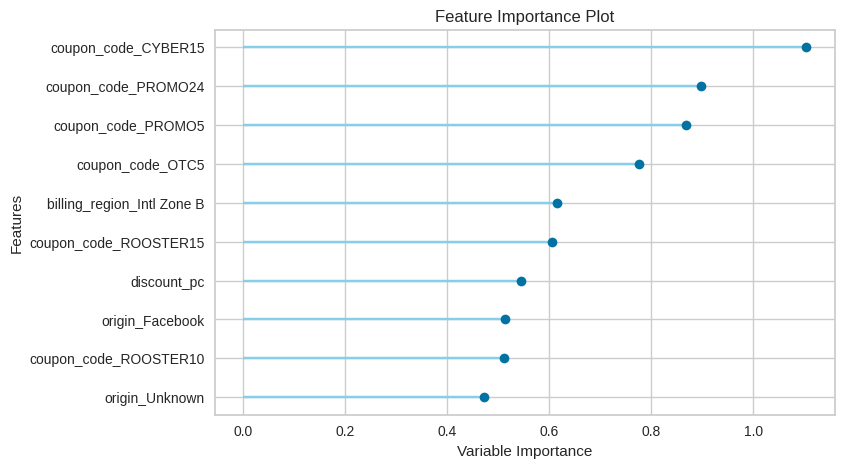

In [17]:
plot_model(model_logistic, plot='feature')

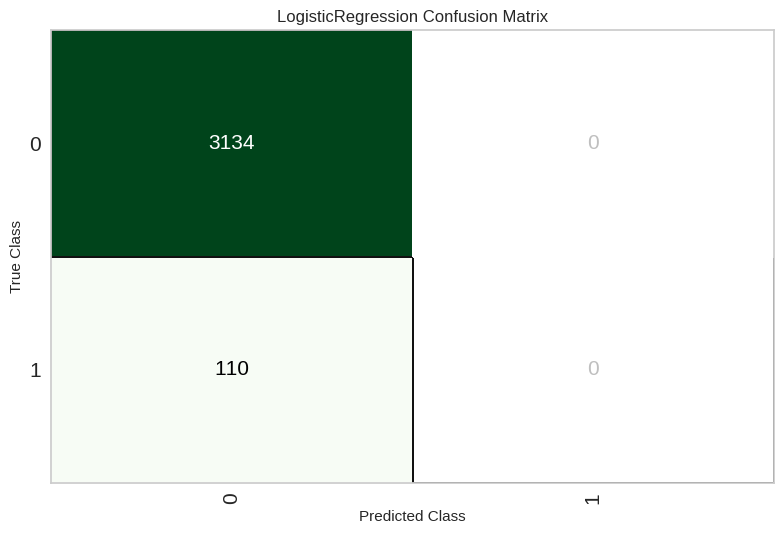

In [18]:
plot_model(model_logistic, plot='confusion_matrix')

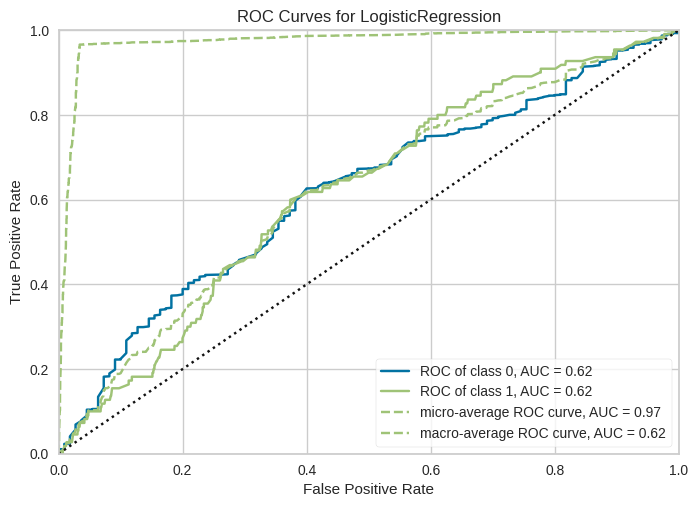

In [19]:
plot_model(model_logistic, plot='auc')  # ROC curve

In [20]:
predictions = predict_model(model_logistic, data=orders_unseen_logistic.drop('bulk', axis=1))
display(predictions.head())

,order_id,customer_email,order_date,order_seq,billing_region,cart_discount,coupon_code,coupon_count,discount_amount_inc_tax,gender_billing,...,discount_pc,coupon_code_cleaned,discount_amount_inc_tax_cleaned,order_cost_cleaned,gender_billing_cleaned,gender_shipping_cleaned,repeat,has_coupon,prediction_label,prediction_score
0,ord_013d2bb771,eml_e6bd9293f4@gmail.example.net,2025-03-26,2,South Australia,6.63,ROOSTER20,1,8.16,f,...,0.25,ROOSTER20,8.16,0.0,f,f,1,1,0,0.9682
1,ord_777dc141ea,eml_e6db6f607a@gmail.example.net,2024-04-03,1,South Australia,0.74,ROOSTER5,1,0.74,f,...,0.05,ROOSTER5,0.74,4.0,f,f,0,1,0,0.9792
2,ord_e220af511e,eml_e7006b1a88@gmail.example.net,2024-03-24,1,Queensland,0.00,NaN,0,NaN,m,...,0.00,non-coupon,0.00,4.0,m,m,1,0,0,0.9694
3,ord_3c5a387a4e,eml_e7006b1a88@gmail.example.net,2025-04-06,2,Queensland,5.01,ROOSTER20,1,6.16,m,...,0.25,ROOSTER20,6.16,0.0,m,m,1,1,0,0.9817
4,ord_a3075f073f,eml_e70636b973@gmail.example.net,2024-04-04,1,Intl Zone C,1.49,ROOSTER5,1,1.49,m,...,0.05,ROOSTER5,1.49,8.0,m,m,1,1,0,0.9737


In [21]:
performance = pull()
accuracy = performance['Accuracy'][0]
precision = performance['Prec.'][0]
recall = performance['Recall'][0]
print(f'Accuracy: model correctly predicted {accuracy:.2%} of the time')
print(f'Precision:   {precision:.2%} reliable')
print(f'Recall: model correctly identified {recall:.2%} of the customers who bulk')

Accuracy: model correctly predicted 96.57% of the time
Precision:   0.00% reliable
Recall: model correctly identified 0.00% of the customers who bulk


In [22]:
final_model = finalize_model(model_logistic)

## Traslate to Business

Which discount and coupon strategies most effectively increase bulk orders without destroying margins?

In [23]:
# Get predictions for ALL rows (PyCaret reuses preprocessing)
predictions = predict_model(final_model, data=orders)

# Add to original DataFrame
orders['pred_bulk_prob'] = predictions['prediction_score']  # P(bulk=1)
orders['pred_bulk']      = predictions['prediction_label']  # 0/1
orders['actual_bulk']    = orders[target_column]


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Logistic Regression,0.9663,0.6900,0.0000,0.0000,0.0000,0.0000,0.0000


In [24]:

orders['actual_bulk'].mean()


0.033719090833402715

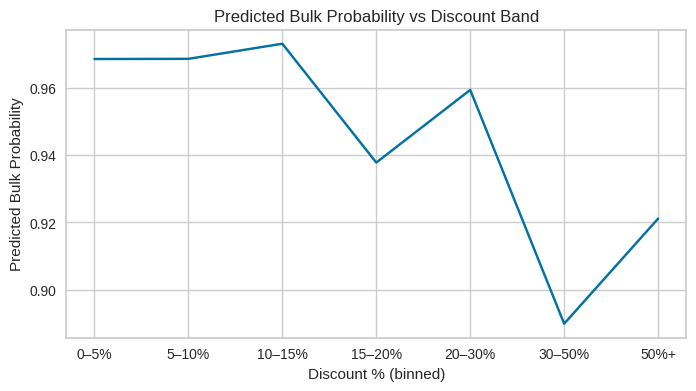

In [25]:

# Create discount bins
bins = [0, 0.05, 0.10, 0.15, 0.20, 0.30, 0.50, 1.01]
labels = ['0–5%', '5–10%', '10–15%', '15–20%', '20–30%', '30–50%', '50%+']

orders['discount_band'] = pd.cut(orders['discount_pc'], bins=bins, labels=labels)

# Compute averages PER BIN
summary = orders.groupby('discount_band')['pred_bulk_prob'].mean().reset_index()

# Plot
plt.figure(figsize=(8,4))
plt.plot(summary['discount_band'], summary['pred_bulk_prob'])
plt.xlabel("Discount % (binned)")
plt.ylabel("Predicted Bulk Probability")
plt.title("Predicted Bulk Probability vs Discount Band")
plt.grid(True)
plt.show()


In [26]:

bins   = [0, 0.05, 0.10, 0.15, 0.20, 0.30, 1.01]
labels = ['0–5%', '5–10%', '10–15%', '15–20%', '20–30%', '30%+']

orders['discount_band'] = pd.cut(orders['discount_pc'], bins=bins, labels=labels, include_lowest=True)

discount_summary = (orders.groupby('discount_band').agg(
              orders=('order_total', 'count'),
              avg_discount_pc=('discount_pc', 'mean'),
              avg_order_total=('order_total', 'mean'),
              actual_bulk_rate=('actual_bulk', 'mean'),
              predicted_bulk_rate=('pred_bulk_prob', 'mean')
          )
          .reset_index()
)

print(discount_summary)


  discount_band  orders  avg_discount_pc  avg_order_total  actual_bulk_rate  \
0          0–5%    8234         0.002470        45.261506          0.025383   
1         5–10%    1307         0.067735        47.464836          0.058914   
2        10–15%     403         0.122779        48.320521          0.022333   
3        15–20%    1348         0.180007        49.376231          0.061573   
4        20–30%     686         0.249490        49.679475          0.034985   
5          30%+      16         0.746875        46.011875          0.125000   

   predicted_bulk_rate  
0             0.970655  
1             0.968709  
2             0.973210  
3             0.937820  
4             0.959461  
5             0.915262  


In [27]:
coupon_summary = (orders.groupby('coupon_code').agg(
              orders=('order_total', 'count'),
              avg_discount_pc=('discount_pc', 'mean'),
              avg_order_total=('order_total', 'mean'),
              actual_bulk_rate=('actual_bulk', 'mean'),
              predicted_bulk_rate=('pred_bulk_prob', 'mean')
          )
          .sort_values('predicted_bulk_rate', ascending=False)
)

print(coupon_summary.head(10))


             orders  avg_discount_pc  avg_order_total  actual_bulk_rate  \
coupon_code                                                               
OTC5             38         0.060000        46.999211          0.000000   
CYBER15         240         0.180000        42.111292          0.012500   
PROMO20           1         0.250000        14.820000          0.000000   
ROOSTER10       577         0.111612        44.254991          0.019064   
VALENTINE14      14         0.140000        41.334286          0.000000   
ROOSTER5       1413         0.057155        46.569377          0.053786   
PROMO15           2         0.165000        36.345000          0.000000   
ROOSTER20       568         0.249472        51.329366          0.036972   
EASTER15         28         0.150000        41.328929          0.035714   
VOUCHER           1         0.180000        31.630000          0.000000   

             predicted_bulk_rate  
coupon_code                       
OTC5                    0.982

# Predict Discount re purchase  

## Model Prediction

In [28]:
orders['repeat'].head()

,repeat
0,1
1,1
2,0
3,0
4,0


In [29]:
# Create a new combined dataframe
combined_orders_metrics = pd.concat([orders, metrics], axis=1)

# Display the result
display(combined_orders_metrics)

orders_dataset_combined = combined_orders_metrics.sample(frac=0.9, random_state=789).reset_index(drop=True)
orders_unseen_combined = combined_orders_metrics.drop(orders_dataset_combined.index).reset_index(drop=True)

,order_id,customer_email,order_date,order_seq,billing_region,cart_discount,coupon_code,coupon_count,discount_amount_inc_tax,gender_billing,...,days_inactive_onetime,days_inactive_repeat,days_as_customer,days_active,purchase_velocity_days,order_date_second,origin_second,days_to_second_order,repeat_customer,first_order_discount_pc
0,ord_d15b71b179,eml_000087713b@gmail.example.net,2024-03-31,1,South Australia,0.00,NaN,0,NaN,f,...,NaN,378.0,402.0,24.0,24.0,2024-04-24,Google,24.0,1.0,0.0
1,ord_129610b2ec,eml_000087713b@gmail.example.net,2024-04-24,2,South Australia,0.00,NaN,0,NaN,m,...,213.0,NaN,213.0,NaN,NaN,NaT,NaN,NaN,0.0,0.0
2,ord_ada1b29eb6,eml_000c38d267@gmail.example.net,2024-10-06,1,New Zealand,0.00,NaN,0,NaN,f,...,71.0,NaN,71.0,NaN,NaN,NaT,NaN,NaN,0.0,0.0
3,ord_6a3592f364,eml_000f5ee2c8@gmail.example.net,2025-02-25,1,Australian Capital Territory,0.00,NaN,0,NaN,f,...,175.0,NaN,175.0,NaN,NaN,NaT,NaN,NaN,0.0,0.0
4,ord_84117c1eec,eml_002c47b125@gmail.example.net,2024-11-13,1,South Australia,0.00,NaN,0,NaN,f,...,NaN,141.0,293.0,152.0,76.0,2024-07-24,Facebook,6.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12006,ord_2d8fa0eedc,eml_ffe19da566@gmail.example.net,2025-03-06,2,New South Wales,1.37,ROOSTER5,1,1.69,f,...,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN
12007,ord_24012076d8,eml_ffe19da566@gmail.example.net,2025-03-21,3,New South Wales,5.50,ROOSTER20,1,6.76,f,...,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN
12008,ord_f5738f8a9b,eml_ffe19da566@gmail.example.net,2025-03-21,4,New South Wales,2.75,ROOSTER20,1,3.38,f,...,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN
12009,ord_d54ebc6239,eml_ffe3515891@gmail.example.net,2024-09-04,1,Intl Zone B,0.00,NaN,0,NaN,f,...,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN


In [30]:
# The 'repeat' column creation has been moved to an earlier cell to ensure it's present in sampled dataframes.
# features

features_repeat = ['discount_pc','has_coupon','coupon_count','order_total','order_seq','cart_discount','discount_amount_inc_tax','days_to_second_order','days_inactive_repeat','purchase_velocity_days']
#order_seq
features_repeat01 = ['discount_pc','has_coupon','coupon_count','order_total','order_seq','cart_discount','discount_amount_inc_tax','days_to_second_order','days_inactive_repeat','purchase_velocity_days','repeat']

target = 'repeat'
#data_for_setup01 = orders_dataset_combined[features_repeat + [target]]
data_for_setup01 = orders_dataset_combined[features_repeat01]


#display(combined_df)
#display(data_for_setup01)
data_for_setup01.head()
#display(metrics)

,discount_pc,has_coupon,coupon_count,order_total,order_seq,cart_discount,discount_amount_inc_tax,days_to_second_order,days_inactive_repeat,purchase_velocity_days,repeat
0,0.18,1,1,91.56,2,12.72,15.64,11.0,315.0,41.0,1
1,0.06,1,1,18.56,1,0.70,0.84,122.0,329.0,122.0,1
2,0.00,0,0,177.60,1,0.00,NaN,NaN,NaN,NaN,0
3,0.00,0,0,79.40,2,0.00,NaN,7.0,84.0,46.0,1
4,0.00,0,0,39.80,1,0.00,NaN,NaN,NaN,NaN,1


### Decision tree

In [31]:

# features

#features_repeat = ['discount_pc','has_coupon','coupon_count','order_total','order_seq']
#order_seq
#target = 'repeat'


In [32]:
# Create a new DataFrame with only the selected features and the target
#data_for_setup01 = orders_dataset_logistic[features_repeat + ['repeat']]

p_repeat = setup(data=data_for_setup01, target='repeat', session_id=123, normalize=True)
best_model = compare_models()


,Description,Value
0,Session id,123
1,Target,repeat
2,Target type,Binary
3,Original data shape,"(10810, 11)"
4,Transformed data shape,"(10810, 11)"
5,Transformed train set shape,"(7566, 11)"
6,Transformed test set shape,"(3244, 11)"
7,Numeric features,10
8,Rows with missing values,94.0%
9,Preprocess,True


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
lr,Logistic Regression,0.8292,0.8268,0.5836,1.0000,0.7368,0.6231,0.6727,0.0540
gbc,Gradient Boosting Classifier,0.8290,0.8310,0.5865,0.9940,0.7375,0.6229,0.6707,0.5330
ada,Ada Boost Classifier,0.8286,0.8241,0.5852,0.9946,0.7367,0.6219,0.6702,0.3010
ridge,Ridge Classifier,0.8284,0.8008,0.5827,0.9984,0.7356,0.6213,0.6709,0.0400
svm,SVM - Linear Kernel,0.8280,0.8131,0.5852,0.9929,0.7360,0.6208,0.6688,0.0700
lda,Linear Discriminant Analysis,0.8280,0.8015,0.5827,0.9967,0.7352,0.6205,0.6697,0.0460
lightgbm,Light Gradient Boosting Machine,0.8273,0.8369,0.6007,0.9647,0.7401,0.6211,0.6603,0.8010
nb,Naive Bayes,0.8262,0.7740,0.5849,0.9853,0.7339,0.6170,0.6634,0.0710
xgboost,Extreme Gradient Boosting,0.8233,0.8359,0.6020,0.9481,0.7362,0.6132,0.6491,0.1220
et,Extra Trees Classifier,0.8200,0.8274,0.6152,0.9195,0.7369,0.6081,0.6367,0.6740


Processing:   0%|          | 0/65 [00:00<?, ?it/s]

In [33]:
#model_logistic_repeat= create_model('lr')
#model_logistic_repeat = create_model('dt', verbose=False)
model_logistic_repeat = create_model('dt', verbose=False)

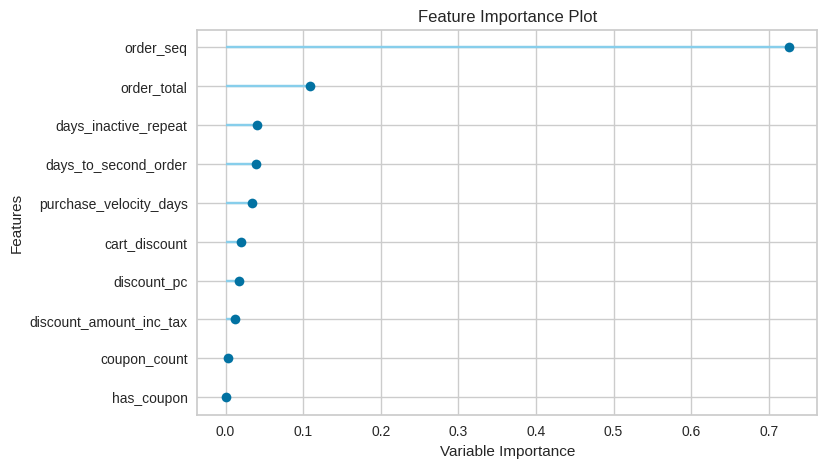

In [34]:
plot_model(model_logistic_repeat, plot='feature')
#plot_model(model_logistic_repeat, plot='confusion_matrix')
#plot_model(model_logistic_repeat, plot='auc')

In [35]:
#predictions = predict_model(model_logistic, data=orders_unseen_logistic.drop('bulk', axis=1))
#display(predictions.head())


In [36]:
predictions_repeat = predict_model(model_logistic_repeat, data=orders_unseen_combined[features_repeat])

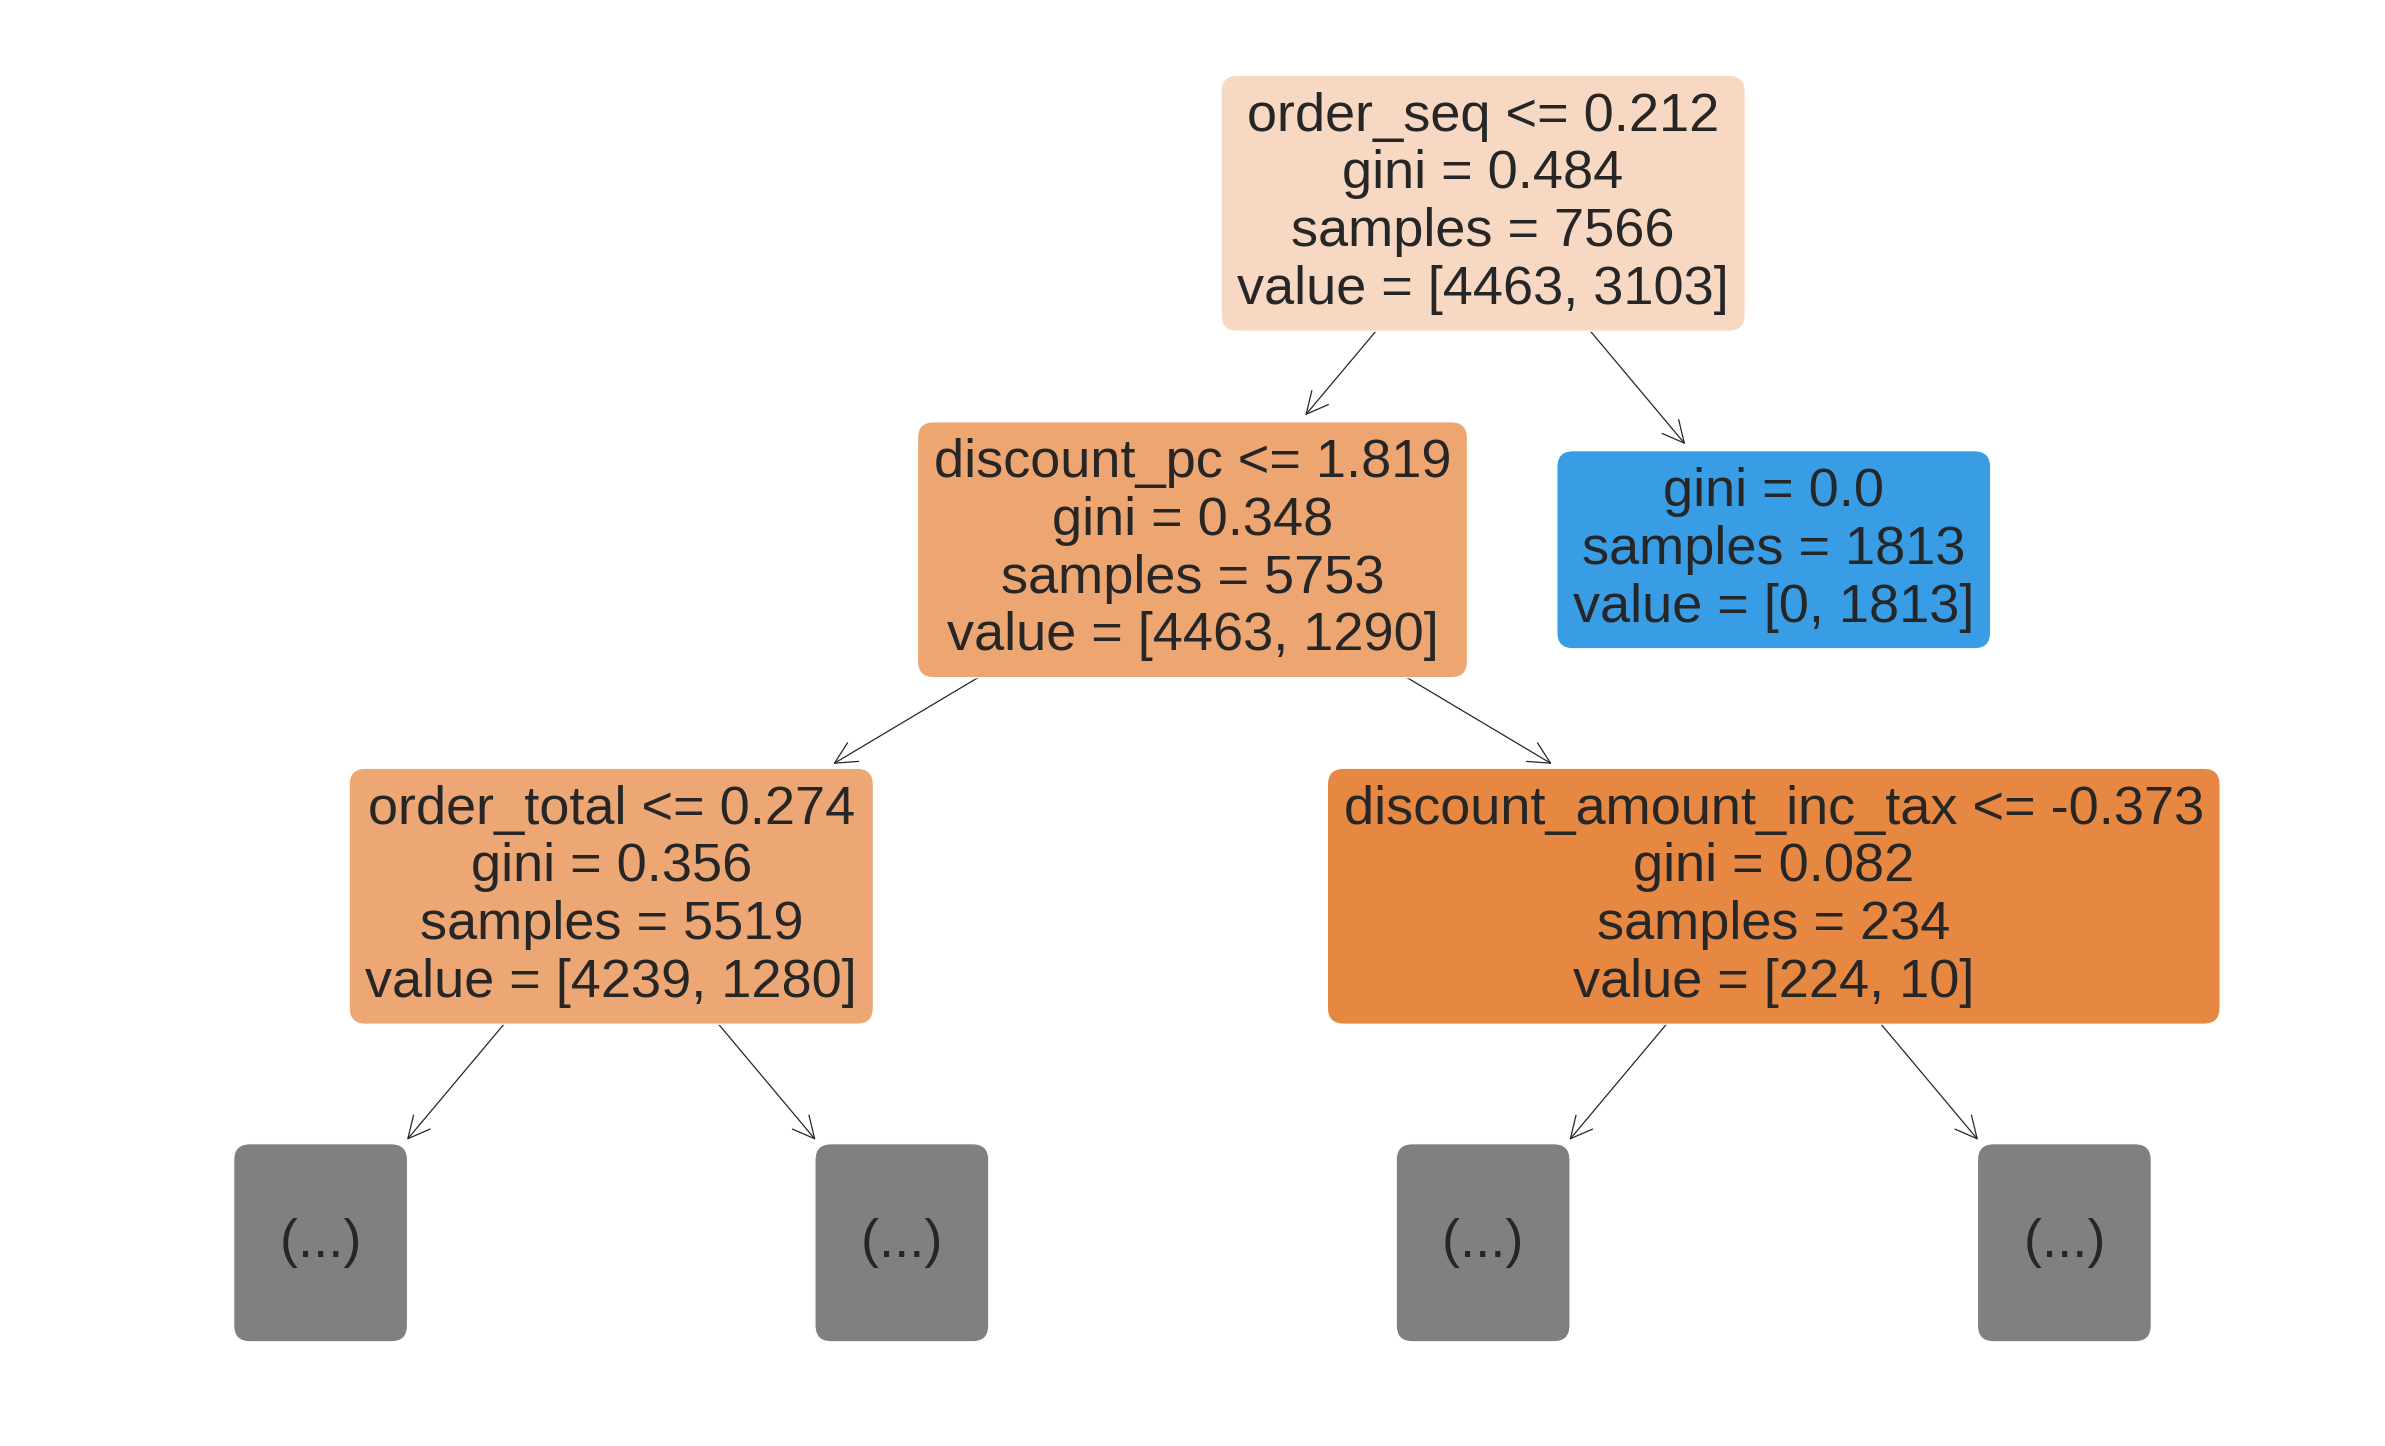

In [37]:
#plot_model(model_logistic_repeat, plot='tree')


plt.figure(figsize=(10, 6), dpi=300)
plot_tree(model_logistic_repeat, max_depth=2, filled=True, feature_names=model_logistic_repeat.feature_names_in_, fontsize=13, rounded=True)
plt.show()
plt.close()

In [38]:
final_model_repeat = finalize_model(model_logistic_repeat)

### Random forrest

In [39]:
p_repeat = setup(data=data_for_setup01, target='repeat', session_id=123, normalize=True)
rf_model = create_model('rf')

,Description,Value
0,Session id,123
1,Target,repeat
2,Target type,Binary
3,Original data shape,"(10810, 11)"
4,Transformed data shape,"(10810, 11)"
5,Transformed train set shape,"(7566, 11)"
6,Transformed test set shape,"(3244, 11)"
7,Numeric features,10
8,Rows with missing values,94.0%
9,Preprocess,True


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.8243,0.8433,0.6161,0.9317,0.7417,0.6168,0.6471
1,0.8256,0.8344,0.6226,0.9279,0.7452,0.6203,0.6489
2,0.8085,0.8245,0.5935,0.9064,0.7173,0.5818,0.6117
3,0.8375,0.8404,0.6431,0.9434,0.7648,0.6474,0.6751
4,0.8085,0.8358,0.5884,0.9150,0.7162,0.5817,0.6141
5,0.8468,0.8597,0.6688,0.9412,0.7820,0.6690,0.6922
6,0.8016,0.8145,0.6129,0.8636,0.7170,0.5709,0.5908
7,0.8148,0.8198,0.5839,0.9427,0.7211,0.5937,0.6319
8,0.8082,0.8221,0.6032,0.8947,0.7206,0.5829,0.6091


Processing:   0%|          | 0/4 [00:00<?, ?it/s]

In [40]:
predictions_repeat_rf = predict_model(rf_model, data=orders_unseen_combined[features_repeat01])
display(predictions_repeat_rf)

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Random Forest Classifier,0.8326,0.8779,0.6280,0.9544,0.7575,0.6379,0.6705


,discount_pc,has_coupon,coupon_count,order_total,order_seq,cart_discount,discount_amount_inc_tax,days_to_second_order,days_inactive_repeat,purchase_velocity_days,repeat,prediction_label,prediction_score
0,0.25,1,1,36.540001,2,6.63,8.16,NaN,NaN,NaN,1,1,1.0000
1,0.05,1,1,18.660000,1,0.74,0.74,NaN,NaN,NaN,0,0,0.7800
2,0.00,0,0,17.400000,1,0.00,NaN,NaN,NaN,NaN,1,0,0.6706
3,0.25,1,1,27.540001,2,5.01,6.16,NaN,NaN,NaN,1,1,0.9900
4,0.05,1,1,30.809999,1,1.49,1.49,NaN,NaN,NaN,1,0,0.8875
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1196,0.06,1,1,35.009998,2,1.37,1.69,NaN,NaN,NaN,1,1,1.0000
1197,0.25,1,1,29.940001,3,5.50,6.76,NaN,NaN,NaN,1,1,1.0000
1198,0.25,1,1,16.420000,4,2.75,3.38,NaN,NaN,NaN,1,1,1.0000
1199,0.00,0,0,71.500000,1,0.00,NaN,NaN,NaN,NaN,0,0,0.8165


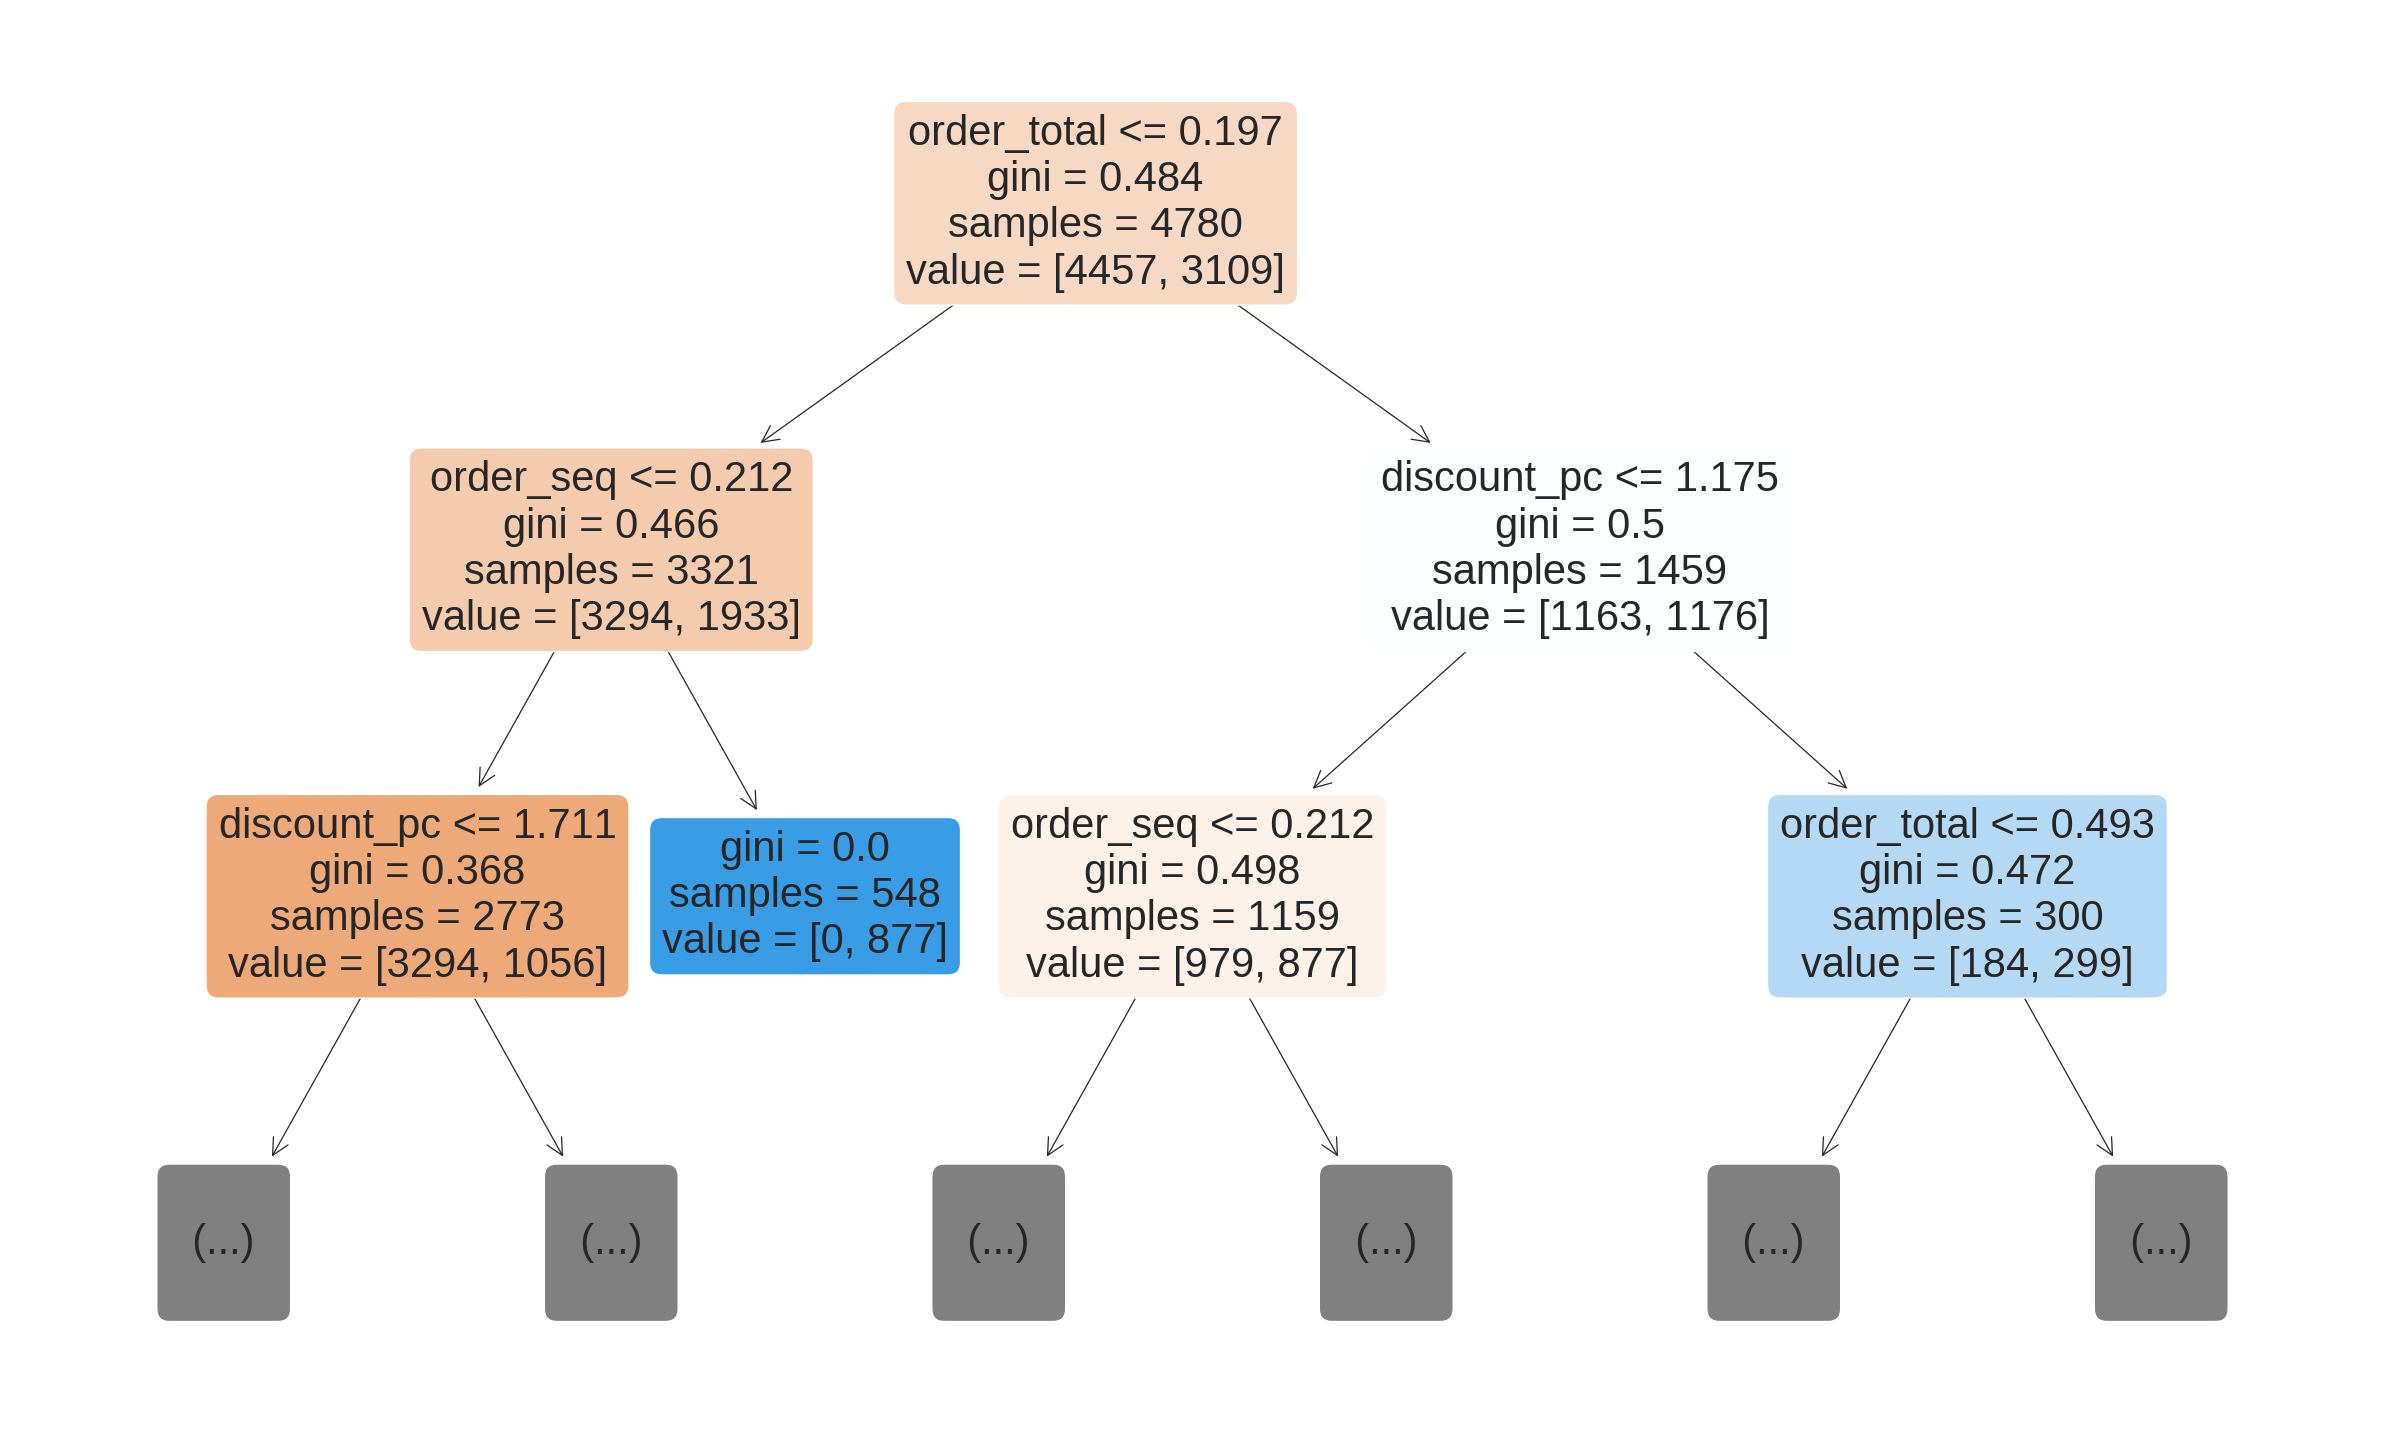

In [41]:


# get the first decision tree in the forest
rf_tree_0 = rf_model.estimators_[0]

# plot the tree
plt.figure(figsize=(10, 6), dpi=300)
plot_tree(rf_tree_0, max_depth=2, filled=True, feature_names=rf_model.feature_names_in_, fontsize=10, rounded=True)
plt.show()
plt.close()

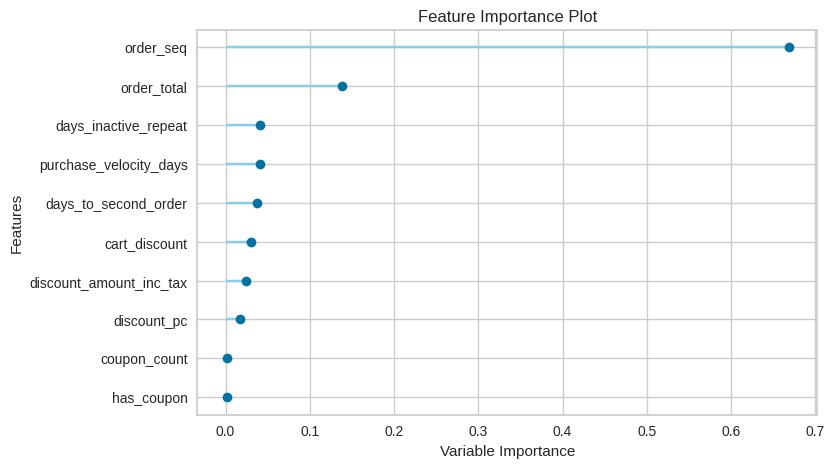

In [42]:
plot_model(rf_model, plot='feature')

In [43]:
final_model_repeat_rf = finalize_model(rf_model)

## Traslate to Business (Repeat)

### new01


In [44]:

discounts = [0.00, 0.10, 0.20, 0.30, 0.50]

scenario_data = pd.DataFrame([
    {'discount_pc': d,
     'order_total': orders['order_total'].mean(),
     'cart_discount' : orders['cart_discount'].mean(),
     'discount_amount_inc_tax' : orders['discount_amount_inc_tax'].mean(),
     'days_to_second_order' : metrics['days_to_second_order'].mean(),
     'days_inactive_repeat' : metrics['days_inactive_repeat'].mean(),
     'purchase_velocity_days' : metrics['purchase_velocity_days'].mean(),
     'coupon_count': 1,
     'has_coupon': 1,
     'order_seq': 1,    # first order
     'scenario': 'Coupon – first order'
    }
    for d in discounts
] + [
    {'discount_pc': d,
     'order_total': orders['order_total'].mean(),
      'cart_discount' : orders['cart_discount'].mean(),
     'discount_amount_inc_tax' : orders['discount_amount_inc_tax'].mean(),
      'days_to_second_order' : metrics['days_to_second_order'].mean(),
     'days_inactive_repeat' : metrics['days_inactive_repeat'].mean(),
     'purchase_velocity_days' : metrics['purchase_velocity_days'].mean(),
     'coupon_count': 1,
     'has_coupon': 1,
     'order_seq': 2,    # returning 2 order
     'scenario': 'Coupon – returning second order'
    }
    for d in discounts
] + [
    {'discount_pc': d,
     'order_total': orders['order_total'].mean(),
    'cart_discount' : orders['cart_discount'].mean(),
     'discount_amount_inc_tax' : orders['discount_amount_inc_tax'].mean(),
      'days_to_second_order' : metrics['days_to_second_order'].mean(),
     'days_inactive_repeat' : metrics['days_inactive_repeat'].mean(),
     'purchase_velocity_days' : metrics['purchase_velocity_days'].mean(),
     'coupon_count': 1,
     'has_coupon': 1,
     'order_seq': 3,    # returning 3 order
     'scenario': 'Coupon – returning third+ order'
    }
    for d in discounts
] )

scenario_data_for_combile = pd.DataFrame([
    {'discount_pc': d,
     'order_total': orders['order_total'].mean(),
      'cart_discount' : orders['cart_discount'].mean(),
     'discount_amount_inc_tax' : orders['discount_amount_inc_tax'].mean(),
     'days_to_second_order' : metrics['days_to_second_order'].mean(),
     'days_inactive_repeat' : metrics['days_inactive_repeat'].mean(),
     'purchase_velocity_days' : metrics['purchase_velocity_days'].mean(),
     'coupon_count': 1,
     'has_coupon': 1,
     'order_seq': 2,    # returning 2 order
     'scenario': 'Coupon – returning second order'
    }
    for d in discounts
] )

scenario_data_for_combile_first = pd.DataFrame([
    {'discount_pc': d,
     'order_total': orders['order_total'].mean(),
      'cart_discount' : orders['cart_discount'].mean(),
     'discount_amount_inc_tax' : orders['discount_amount_inc_tax'].mean(),
     'days_to_second_order' : metrics['days_to_second_order'].mean(),
     'days_inactive_repeat' : metrics['days_inactive_repeat'].mean(),
     'purchase_velocity_days' : metrics['purchase_velocity_days'].mean(),
     'coupon_count': 1,
     'has_coupon': 1,
     'order_seq': 1,    # First orders
     'scenario': 'Coupon – returning second order'
    }
    for d in discounts
] )

In [45]:
scenario_pred = predict_model(final_model_repeat_rf, data=scenario_data)
scenario_data['pred_repeat_prob'] = scenario_pred['prediction_score']

scenario_pred_combile = predict_model(final_model_repeat_rf, data=scenario_data_for_combile)
scenario_data_for_combile['pred_repeat_prob'] = scenario_pred_combile['prediction_score']

scenario_pred_first = predict_model(final_model_repeat_rf, data=scenario_data_for_combile_first)
scenario_data_for_combile_first['pred_repeat_prob'] = scenario_pred_first['prediction_score']


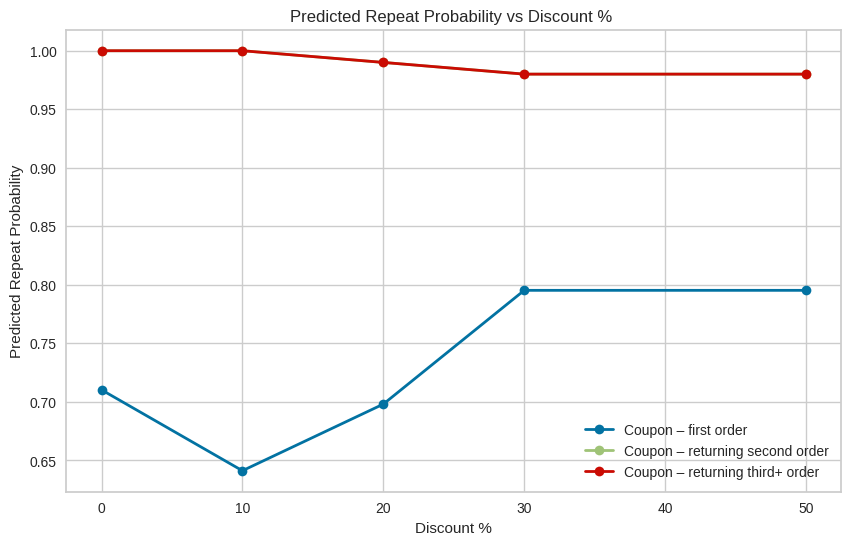

In [46]:

plt.figure(figsize=(10,6))

for scenario in scenario_data['scenario'].unique():
    subset = scenario_data[scenario_data['scenario'] == scenario]
    plt.plot(
        subset['discount_pc'] * 100,
        subset['pred_repeat_prob'],
        marker='o',
        linewidth=2,
        label=scenario
    )

plt.xlabel('Discount %')
plt.ylabel('Predicted Repeat Probability')
plt.title('Predicted Repeat Probability vs Discount % ')
plt.grid(True)
plt.legend()
plt.show()



#Predict Profit from different discount lv  ( Regression )

## check gross margin

In [47]:
#  Gross profit BEFORE discount
orders['profit_before_disc'] = orders['order_subtotal_inc_tax'] - orders['order_cost']

#  Gross profit AFTER discount  ( Revenue - cost of sale )
orders['profit_after_disc'] = (orders['order_subtotal_inc_tax'] - orders['discount_amount_inc_tax'] - orders['order_cost'])

#  Gross margin % AFTER discount   (Revenue - cost of sale ) / revenue
orders['margin_after_disc_pc'] = np.where(orders['order_subtotal_inc_tax'] > 0, orders['profit_after_disc'] / orders['order_subtotal_inc_tax'],np.nan)

In [48]:
# exclude crazy discounts
orders_clean = orders[orders['discount_pc'].between(0, 0.8)]


In [49]:
# Define discount bands
bins   = [0, 0.05, 0.10, 0.15, 0.20, 0.30, 1.01]
labels = ['0–5%', '5–10%', '10–15%', '15–20%', '20–30%', '30%+']

orders['discount_band'] = pd.cut(
    orders['discount_pc'], bins=bins, labels=labels, include_lowest=True
)

profit_summary = (
    orders
      .groupby('discount_band')
      .agg(
          orders_count       = ('order_id', 'count'),
          avg_discount_pc    = ('discount_pc', 'mean'),
          avg_profit_before  = ('profit_before_disc', 'mean'),
          avg_profit_after   = ('profit_after_disc', 'mean'),
          total_profit_after = ('profit_after_disc', 'sum'),
          avg_margin_after   = ('margin_after_disc_pc', 'mean')
      )
      .reset_index()
)

print(profit_summary)


  discount_band  orders_count  avg_discount_pc  avg_profit_before  \
0          0–5%          8234         0.002470          29.204337   
1         5–10%          1307         0.067735          33.905032   
2        10–15%           403         0.122779          34.379266   
3        15–20%          1348         0.180007          39.968624   
4        20–30%           686         0.249490          40.282945   
5          30%+            16         0.746875          68.961538   

   avg_profit_after  total_profit_after  avg_margin_after  
0         25.184303            10124.09          0.680235  
1         31.195958            38745.38          0.675858  
2         29.367645             7606.22          0.639001  
3         31.846727            33566.45          0.598985  
4         29.471829            12407.64          0.553374  
5         24.606923              319.89          0.164966  


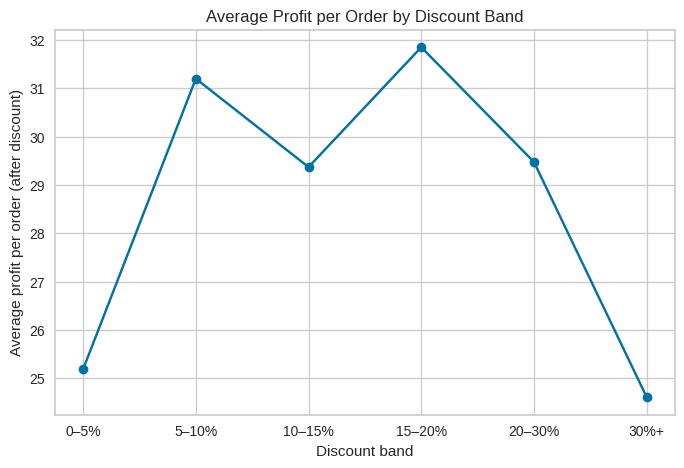

In [50]:
# not use
plt.figure(figsize=(8,5))
plt.plot(
    profit_summary['discount_band'],
    profit_summary['avg_profit_after'],
    marker='o'
)
plt.xlabel('Discount band')
plt.ylabel('Average profit per order (after discount)')
plt.title('Average Profit per Order by Discount Band')
plt.grid(True)
plt.show()


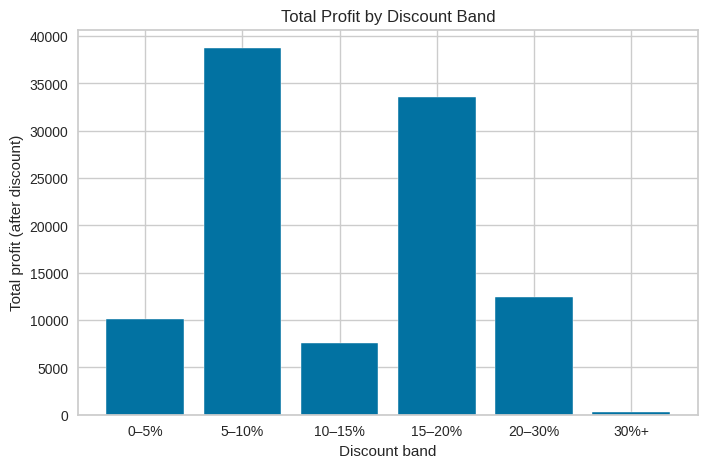

In [51]:
# not use
plt.figure(figsize=(8,5))
plt.bar(
    profit_summary['discount_band'],
    profit_summary['total_profit_after']
)
plt.xlabel('Discount band')
plt.ylabel('Total profit (after discount)')
plt.title('Total Profit by Discount Band')
plt.show()


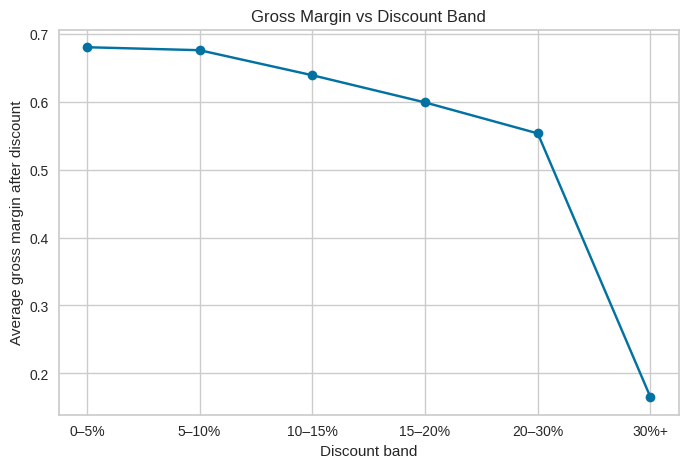

In [52]:
plt.figure(figsize=(8,5))
plt.plot(
    profit_summary['discount_band'],
    profit_summary['avg_margin_after'],
    marker='o'
)
plt.xlabel('Discount band')
plt.ylabel('Average gross margin after discount')
plt.title('Gross Margin vs Discount Band')
plt.grid(True)
plt.show()


## Model prediction


In [53]:
features_profit = ['discount_pc','order_total','coupon_count','has_coupon','order_units','order_seq']
data_profit = orders[features_profit + ['profit_after_disc']].copy()

# Drop rows with NaN in the target column
data_profit.dropna(subset=['profit_after_disc'], inplace=True)


orders_dataset_profit = data_profit.sample(frac=0.9, random_state=789)
orders_unseen_profit = data_profit.drop(orders_dataset_profit.index)

# Now, reset the index for both if desired
orders_dataset_profit = orders_dataset_profit.reset_index(drop=True)
orders_unseen_profit = orders_unseen_profit.reset_index(drop=True)




In [54]:
profit_model = setup_reg(data=orders_dataset_profit, target='profit_after_disc', session_id=123)
best_model_profit = compare_models_reg()

,Description,Value
0,Session id,123
1,Target,profit_after_disc
2,Target type,Regression
3,Original data shape,"(3054, 7)"
4,Transformed data shape,"(3054, 7)"
5,Transformed train set shape,"(2137, 7)"
6,Transformed test set shape,"(917, 7)"
7,Numeric features,6
8,Preprocess,True
9,Imputation type,simple


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
lr,Linear Regression,0.7051,0.8222,0.9055,0.9979,0.0381,0.0316,0.0260
ridge,Ridge Regression,0.7065,0.8226,0.9058,0.9979,0.0373,0.0314,0.0220
lar,Least Angle Regression,0.7049,0.8235,0.9063,0.9979,0.0386,0.0318,0.0240
br,Bayesian Ridge,0.7055,0.8227,0.9058,0.9979,0.0380,0.0316,0.0230
huber,Huber Regressor,0.6951,0.8389,0.9147,0.9978,0.0350,0.0299,0.1150
et,Extra Trees Regressor,0.1512,1.2114,0.9881,0.9968,0.0258,0.0069,0.1950
gbr,Gradient Boosting Regressor,0.4137,1.6526,1.1798,0.9959,0.0433,0.0175,0.2410
rf,Random Forest Regressor,0.2022,1.9227,1.1718,0.9955,0.0305,0.0071,0.2700
par,Passive Aggressive Regressor,0.9423,1.7085,1.2745,0.9954,0.0430,0.0356,0.0250
dt,Decision Tree Regressor,0.2007,1.9060,1.2493,0.9952,0.0434,0.0105,0.0310


Processing:   0%|          | 0/81 [00:00<?, ?it/s]

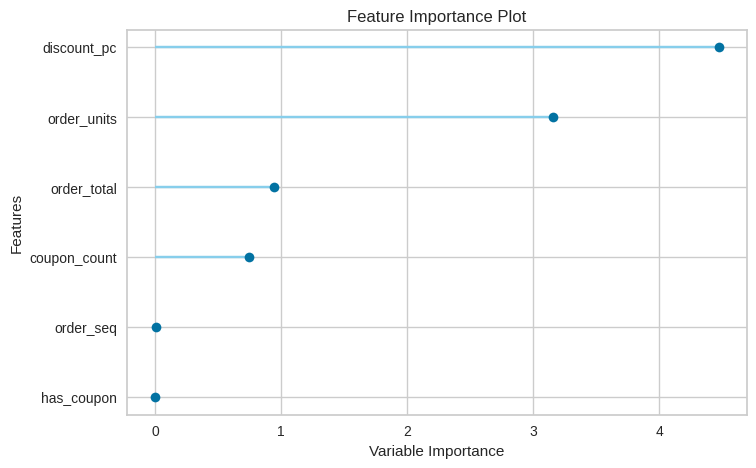

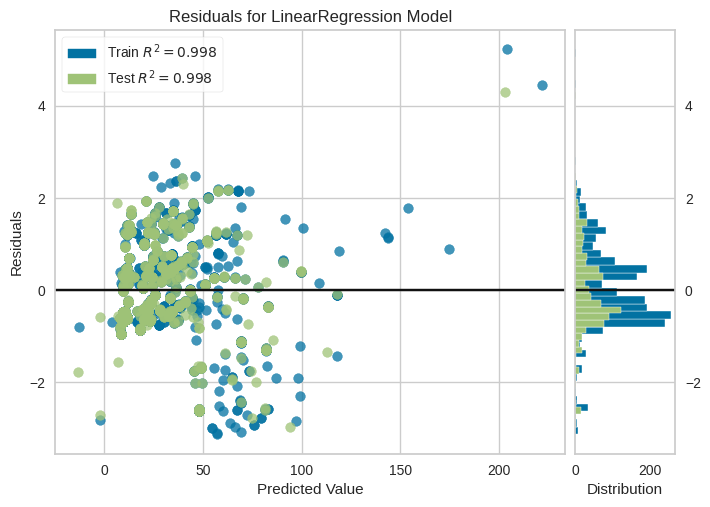

In [55]:
plot_model_reg(best_model_profit, plot='feature')
plot_model_reg(best_model_profit, plot='residuals')

In [56]:
final_reg_model = finalize_model_reg(best_model_profit)

## Traslate to Business ( Profit )


### Display profit vs discount

In [57]:
reg_pred_all = predict_model(final_reg_model, data=orders_dataset_profit)
orders['predicted_profit'] = reg_pred_all['prediction_label']


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,LinearRegression,0,0,0,0,0,0,0


### Display Gross profif margin vs discount A

,discount_pc,order_total,coupon_count,has_coupon,order_units,order_seq,predicted_profit,predicted_gpm
0,0.00,45.360415,1,1,3.0,1,30,0.661370
1,0.05,43.092394,1,1,3.0,1,28,0.617278
2,0.10,40.824373,1,1,3.0,1,25,0.551141
3,0.20,36.288332,1,1,3.0,1,21,0.462959
4,0.30,31.752290,1,1,3.0,1,16,0.352730
5,0.50,22.680207,1,1,3.0,1,7,0.154320


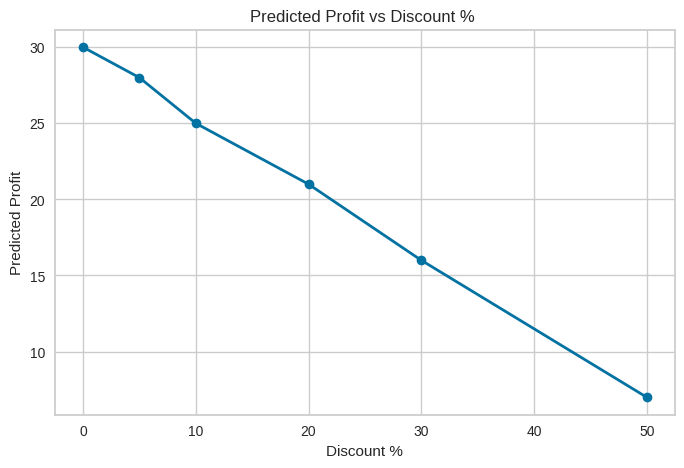

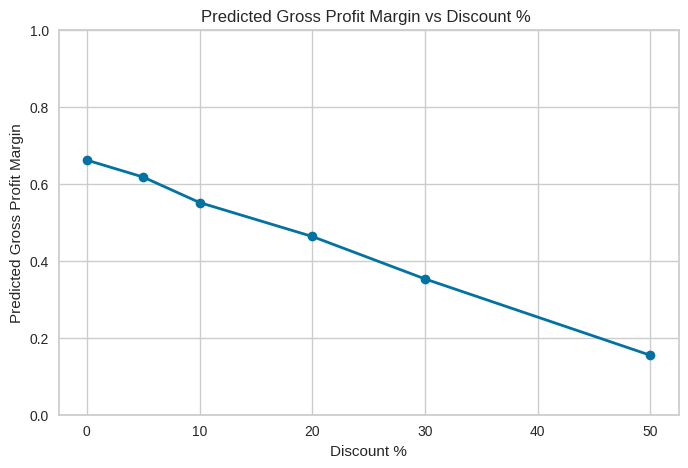

In [58]:


#  value BEFORE discount
base_subtotal = orders['order_subtotal_inc_tax'].mean()

discounts = [0.00, 0.05, 0.10, 0.20, 0.30, 0.50]

# Build scenario data for profit model
scenario_df = pd.DataFrame({
    'discount_pc': discounts,
    'order_total': [base_subtotal * (1 - d) for d in discounts],  # after discount
    'coupon_count': 1,
    'has_coupon': 1,
    'order_units': orders['order_units'].median(),
    'order_seq': 1,      #  returning order
})   # make many graph change this for present

# Get predicted profit from  regression model
scenario_pred = predict_model(final_reg_model, data=scenario_df)
scenario_df['predicted_profit'] = scenario_pred['prediction_label']

# create predicted gross profit margin
scenario_df['predicted_gpm'] = scenario_df['predicted_profit'] / base_subtotal

display(scenario_df)

#  Plot Predicted Profit vs Discount %
plt.figure(figsize=(8,5))
plt.plot(scenario_df['discount_pc']*100,
         scenario_df['predicted_profit'],
         marker='o', linewidth=2)
plt.xlabel('Discount %')
plt.ylabel('Predicted Profit')
plt.title('Predicted Profit vs Discount % ')
plt.grid(True)
plt.show()

#  Plot Predicted Gross Profit Margin vs Discount %   USE THIS
plt.figure(figsize=(8,5))
plt.plot(scenario_df['discount_pc']*100,
         scenario_df['predicted_gpm'],
         marker='o', linewidth=2)
plt.xlabel('Discount %')
plt.ylabel('Predicted Gross Profit Margin')
plt.title('Predicted Gross Profit Margin vs Discount % ')
plt.ylim(0, 1)
plt.grid(True)
plt.show()


# Combile 2 results   profit and repeat customers

In [59]:
combined = scenario_df.merge(
    scenario_data_for_combile[['discount_pc','pred_repeat_prob']],
    on='discount_pc'
)

combined['expected_value'] = (
    combined['predicted_profit'] * combined['pred_repeat_prob']
)

display(combined)

,discount_pc,order_total,coupon_count,has_coupon,order_units,order_seq,predicted_profit,predicted_gpm,pred_repeat_prob,expected_value
0,0.0,45.360415,1,1,3.0,1,30,0.661370,1.00,30.00
1,0.1,40.824373,1,1,3.0,1,25,0.551141,1.00,25.00
2,0.2,36.288332,1,1,3.0,1,21,0.462959,0.99,20.79
3,0.3,31.752290,1,1,3.0,1,16,0.352730,0.98,15.68
4,0.5,22.680207,1,1,3.0,1,7,0.154320,0.98,6.86


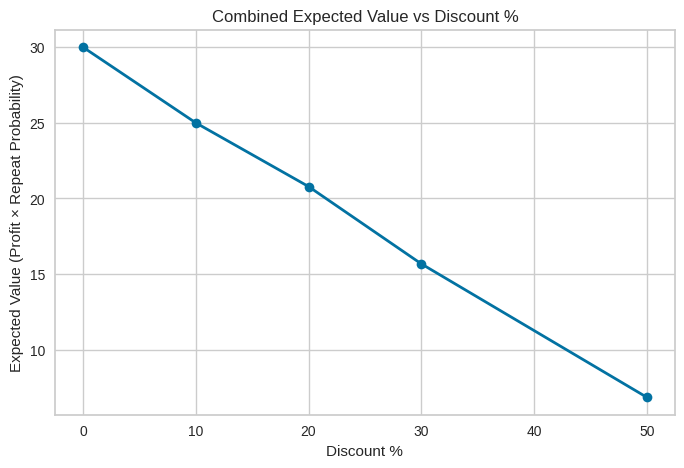

In [60]:
plt.figure(figsize=(8,5))
plt.plot(combined['discount_pc']*100,
         combined['expected_value'],
         marker='o',
         linewidth=2)

plt.xlabel("Discount %")
plt.ylabel("Expected Value (Profit × Repeat Probability)")
plt.title("Combined Expected Value vs Discount %")
plt.grid(True)
plt.show()


# Combile 2 results profit and first customers

In [61]:
combined_first = scenario_df.merge(
    scenario_data_for_combile_first[['discount_pc','pred_repeat_prob']],
    on='discount_pc'
)

combined_first['expected_value'] = (
    combined_first['predicted_profit'] * combined_first['pred_repeat_prob']
)

display(combined_first)

,discount_pc,order_total,coupon_count,has_coupon,order_units,order_seq,predicted_profit,predicted_gpm,pred_repeat_prob,expected_value
0,0.0,45.360415,1,1,3.0,1,30,0.661370,0.7103,21.3090
1,0.1,40.824373,1,1,3.0,1,25,0.551141,0.6412,16.0300
2,0.2,36.288332,1,1,3.0,1,21,0.462959,0.6981,14.6601
3,0.3,31.752290,1,1,3.0,1,16,0.352730,0.7953,12.7248
4,0.5,22.680207,1,1,3.0,1,7,0.154320,0.7953,5.5671


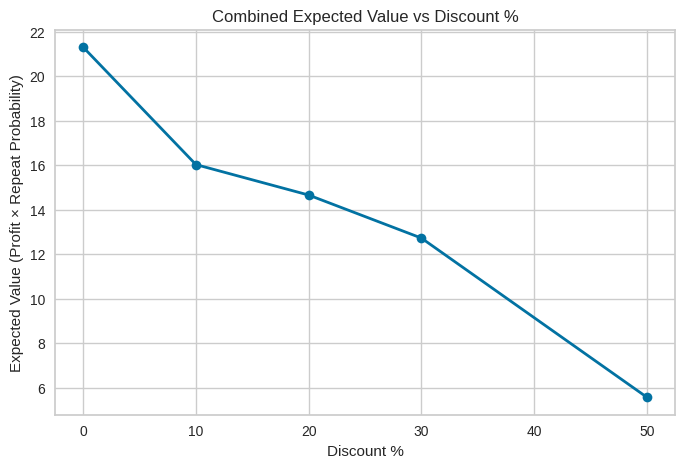

In [62]:
plt.figure(figsize=(8,5))
plt.plot(combined_first['discount_pc']*100,
         combined_first['expected_value'],
         marker='o',
         linewidth=2)

plt.xlabel("Discount %")
plt.ylabel("Expected Value (Profit × Repeat Probability)")
plt.title("Combined Expected Value vs Discount %")
plt.grid(True)
plt.show()

#Compare Gross Profit Margin vs Predicted Repeat Probability

In [63]:



#    Low  = bottom 25%
#    Mid  = middle 50%
#    High = top 25%
combined['margin_cluster'] = pd.qcut(
    combined['predicted_gpm'],
    q=[0, 0.25, 0.75, 1.0],
    labels=['Low margin', 'Mid margin', 'High margin']
)


cluster_summary = (
    combined
      .groupby('margin_cluster')
      .agg(
          avg_margin=('predicted_gpm', 'mean'),
          avg_repeat_prob=('pred_repeat_prob', 'mean'),
          avg_profit=('predicted_profit', 'mean'),
          customer_count=('predicted_gpm', 'size')
      )
      .reset_index()
)


cluster_summary['expected_value'] = (
    cluster_summary['avg_profit'] * cluster_summary['avg_repeat_prob']
)

print(cluster_summary)


  margin_cluster  avg_margin  avg_repeat_prob  avg_profit  customer_count  \
0     Low margin    0.253525            0.980        11.5               2   
1     Mid margin    0.507050            0.995        23.0               2   
2    High margin    0.661370            1.000        30.0               1   

   expected_value  
0          11.270  
1          22.885  
2          30.000  


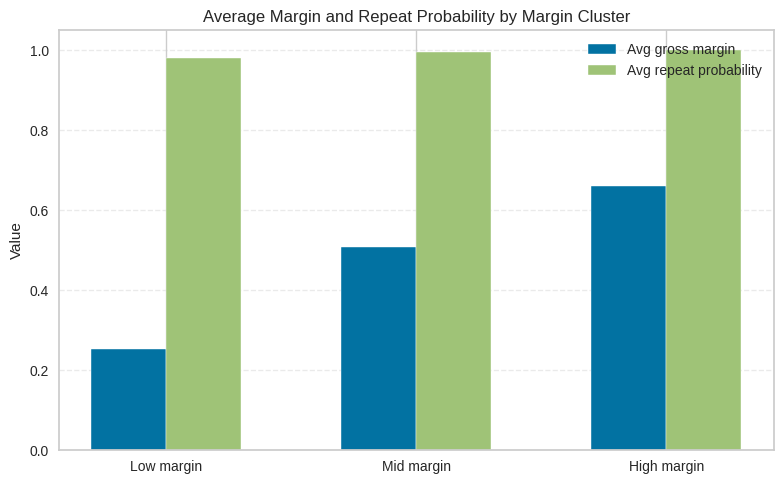

In [64]:
# Bar chart: margin and repeat probability side-by-side
x = range(len(cluster_summary))

plt.figure(figsize=(8,5))
plt.bar([i - 0.15 for i in x], cluster_summary['avg_margin'],
        width=0.3, label='Avg gross margin')
plt.bar([i + 0.15 for i in x], cluster_summary['avg_repeat_prob'],
        width=0.3, label='Avg repeat probability')

plt.xticks(x, cluster_summary['margin_cluster'])
plt.ylabel('Value')
plt.title('Average Margin and Repeat Probability by Margin Cluster')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()
